In [2]:

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [3]:
# ============================================================== 
# Parámetros generales
# ============================================================== 
CSV_GAME = "../../../data/inputs/csv/game.csv"
CSV_LINE = "../../../data/inputs/csv/line_score.csv"
CSV_OTHER = "../../../data/inputs/csv/other_stats.csv"
RANDOM_STATE = 42
EWMA_SPAN = 8
ELO_K = 20
INITIAL_ELO = 1500
DECAY_FACTOR = 0.98

# ============================================================== 
# 1. Carga de datos
# ============================================================== 
games = pd.read_csv(CSV_GAME)
line_score = pd.read_csv(CSV_LINE)
other_stats = pd.read_csv(CSV_OTHER)

games['game_date'] = pd.to_datetime(games['game_date'], errors='coerce')
games = games.sort_values('game_date').reset_index(drop=True)
games['game_id'] = games.index
games['home_win'] = (games['pts_home'] > games['pts_away']).astype(int)


In [19]:

# ============================================================== 
# 2. Filtrar datos (excluyendo 2020)
# ============================================================== 
games = games[games['game_date'].dt.year != 2020].copy()


In [20]:

# ============================================================== 
# 3. Cálculo de ELO mejorado
# ============================================================== 
print("Calculando ELO mejorado...")
teams = pd.unique(games[['team_id_home', 'team_id_away']].values.ravel())
elo = {t: INITIAL_ELO for t in teams}
elo_history = []

for _, row in games.iterrows():
    h, a = row['team_id_home'], row['team_id_away']
    he, ae = elo[h], elo[a]
    elo_history.append((he, ae))
    exp_h = 1.0 / (1.0 + 10 ** ((ae - he) / 400.0))
    actual_h = 1.0 if row['pts_home'] > row['pts_away'] else 0.0
    elo[h] += ELO_K * (actual_h - exp_h)
    elo[a] += ELO_K * ((1 - actual_h) - (1 - exp_h))

games['elo_home'] = [e[0] for e in elo_history]
games['elo_away'] = [e[1] for e in elo_history]
games['elo_diff'] = games['elo_home'] - games['elo_away']
games['elo_home_advantage'] = games['elo_home'] + 100
games['elo_diff_advanced'] = games['elo_home_advantage'] - games['elo_away']


Calculando ELO mejorado...


In [21]:
# ============================================================== 
# 4. Procesamiento de line_score
# ============================================================== 
pts_cols_home = [c for c in line_score.columns if c.startswith('pts_qrt') and c.endswith('_home')]
pts_cols_away = [c for c in line_score.columns if c.startswith('pts_qrt') and c.endswith('_away')]

if pts_cols_home and pts_cols_away:
    line_score['home_total_pts'] = line_score[pts_cols_home].sum(axis=1)
    line_score['away_total_pts'] = line_score[pts_cols_away].sum(axis=1)
    line_score['diff_pts_line'] = line_score['home_total_pts'] - line_score['away_total_pts']
else:
    line_score['diff_pts_line'] = 0

games = games.merge(line_score[['game_id', 'diff_pts_line']], on='game_id', how='left')

In [22]:

# ============================================================== 
# 5. Procesamiento de other_stats
# ============================================================== 
other_stats.columns = [c.lower() for c in other_stats.columns]

other_stats['diff_pts_paint'] = other_stats['pts_paint_home'] - other_stats['pts_paint_away']
other_stats['diff_pts_2nd_chance'] = other_stats['pts_2nd_chance_home'] - other_stats['pts_2nd_chance_away']
other_stats['diff_pts_fb'] = other_stats['pts_fb_home'] - other_stats['pts_fb_away']
other_stats['diff_largest_lead'] = other_stats['largest_lead_home'] - other_stats['largest_lead_away']
other_stats['diff_team_turnovers'] = other_stats['team_turnovers_home'] - other_stats['team_turnovers_away']
other_stats['diff_total_turnovers'] = other_stats['total_turnovers_home'] - other_stats['total_turnovers_away']
other_stats['diff_team_rebounds'] = other_stats['team_rebounds_home'] - other_stats['team_rebounds_away']
other_stats['diff_pts_off_to'] = other_stats['pts_off_to_home'] - other_stats['pts_off_to_away']

diff_cols = [
    'game_id', 'diff_pts_paint', 'diff_pts_2nd_chance', 'diff_pts_fb',
    'diff_largest_lead', 'diff_team_turnovers', 'diff_total_turnovers',
    'diff_team_rebounds', 'diff_pts_off_to'
]

games = games.merge(other_stats[diff_cols], on='game_id', how='left')


In [23]:
# ============================================================== 
# 6. Cálculo de estadísticas EWMA y rachas
# ============================================================== 
print("Calculando estadísticas EWMA mejoradas...")
home_cols = ['game_id', 'game_date', 'team_id_home', 'pts_home', 'fgm_home', 'fga_home',
             'fg3m_home', 'fg3a_home', 'ftm_home', 'fta_home', 'reb_home', 'ast_home']
away_cols = ['game_id', 'game_date', 'team_id_away', 'pts_away', 'fgm_away', 'fga_away',
             'fg3m_away', 'fg3a_away', 'ftm_away', 'fta_away', 'reb_away', 'ast_away']

home_df = games[home_cols].copy().rename(columns={
    'team_id_home': 'team_id', 'pts_home': 'pts', 'fgm_home': 'fgm', 'fga_home': 'fga',
    'fg3m_home': 'fg3m', 'fg3a_home': 'fg3a', 'ftm_home': 'ftm', 'fta_home': 'fta',
    'reb_home': 'reb', 'ast_home': 'ast'})
home_df['is_home'] = 1

away_df = games[away_cols].copy().rename(columns={
    'team_id_away': 'team_id', 'pts_away': 'pts', 'fgm_away': 'fgm', 'fga_away': 'fga',
    'fg3m_away': 'fg3m', 'fg3a_away': 'fg3a', 'ftm_away': 'ftm', 'fta_away': 'fta',
    'reb_away': 'reb', 'ast_away': 'ast'})
away_df['is_home'] = 0

team_games = pd.concat([home_df, away_df], ignore_index=True).sort_values(['team_id', 'game_date']).reset_index(drop=True)

team_games['win'] = 0
for idx, row in team_games.iterrows():
    result = games.loc[games['game_id'] == row['game_id'], 'home_win'].values[0]
    team_games.at[idx, 'win'] = result if row['is_home'] == 1 else 1 - result

ewma_stats = ['pts', 'fgm', 'fga', 'fg3m', 'fg3a', 'ftm', 'fta', 'reb', 'ast', 'win']
ewma_list = []

for team, grp in team_games.groupby('team_id', sort=False):
    grp = grp.sort_values('game_date').copy()
    grp['streak5'] = grp['win'].rolling(5, min_periods=1).mean().shift(1)
    grp['last10_wins'] = grp['win'].rolling(10, min_periods=1).mean().shift(1)
    ewm_8 = grp[ewma_stats].ewm(span=8, adjust=False).mean().shift(1)
    ewm_8.columns = [f'ewm8_{c}' for c in ewma_stats]
    ewm_15 = grp[ewma_stats].ewm(span=15, adjust=False).mean().shift(1)
    ewm_15.columns = [f'ewm15_{c}' for c in ewma_stats]
    out = pd.concat([grp.reset_index(drop=True), ewm_8.reset_index(drop=True), ewm_15.reset_index(drop=True)], axis=1)
    ewma_list.append(out)

team_games_ewm = pd.concat(ewma_list, ignore_index=True)

rename_home, rename_away = {}, {}
for s in ewma_stats:
    rename_home[f'ewm8_{s}'] = f'home_ewm8_{s}'
    rename_home[f'ewm15_{s}'] = f'home_ewm15_{s}'
    rename_away[f'ewm8_{s}'] = f'away_ewm8_{s}'
    rename_away[f'ewm15_{s}'] = f'away_ewm15_{s}'

rename_home.update({'streak5': 'home_streak5', 'last10_wins': 'home_last10_wins'})
rename_away.update({'streak5': 'away_streak5', 'last10_wins': 'away_last10_wins'})

home_ewm = team_games_ewm[team_games_ewm['is_home'] == 1][
    ['game_id', 'streak5', 'last10_wins'] + [f'ewm8_{s}' for s in ewma_stats] + [f'ewm15_{s}' for s in ewma_stats]
].rename(columns=rename_home)
away_ewm = team_games_ewm[team_games_ewm['is_home'] == 0][
    ['game_id', 'streak5', 'last10_wins'] + [f'ewm8_{s}' for s in ewma_stats] + [f'ewm15_{s}' for s in ewma_stats]
].rename(columns=rename_away)

games = games.merge(home_ewm, on='game_id', how='left')
games = games.merge(away_ewm, on='game_id', how='left')


Calculando estadísticas EWMA mejoradas...


In [24]:
# ============================================================== 
# 7. Head-to-head histórico
# ============================================================== 
print("Calculando head-to-head histórico")

def calculate_h2h(df):
    h2h_records = {}
    results = []
    for _, row in df.iterrows():
        home, away = row['team_id_home'], row['team_id_away']
        key = tuple(sorted([home, away]))
        if key not in h2h_records:
            h2h_records[key] = {'games': 0, 'home_wins': 0}
        current_record = h2h_records[key].copy()
        h2h_win_pct = current_record['home_wins'] / max(current_record['games'], 1)
        results.append(h2h_win_pct)
        h2h_records[key]['games'] += 1
        if row['home_win'] == 1:
            h2h_records[key]['home_wins'] += 1
    return results

games['h2h_home_win_pct'] = calculate_h2h(games)


Calculando head-to-head histórico


In [25]:
# ============================================================== 
# 8. Cálculo de días de descanso
# ============================================================== 
print("Calculando días de descanso...")
games = games.sort_values(['team_id_home', 'game_date']).reset_index(drop=True)
games['home_days_rest'] = games.groupby('team_id_home')['game_date'].diff().dt.days.fillna(7)
games['away_days_rest'] = games.groupby('team_id_away')['game_date'].diff().dt.days.fillna(7)
games['rest_advantage'] = games['home_days_rest'] - games['away_days_rest']

Calculando días de descanso...


In [26]:
# ============================================================== 
# 9. Creación de features finales
# ============================================================== 
print("Creando features finales...")

games['fg_eff_home'] = games['home_ewm8_fgm'] / (games['home_ewm8_fga'] + 1e-6)
games['fg_eff_away'] = games['away_ewm8_fgm'] / (games['away_ewm8_fga'] + 1e-6)
games['ft_eff_home'] = games['home_ewm8_ftm'] / (games['home_ewm8_fta'] + 1e-6)
games['ft_eff_away'] = games['away_ewm8_ftm'] / (games['away_ewm8_fta'] + 1e-6)
games['fg3_eff_home'] = games['home_ewm8_fg3m'] / (games['home_ewm8_fg3a'] + 1e-6)
games['fg3_eff_away'] = games['away_ewm8_fg3m'] / (games['away_ewm8_fg3a'] + 1e-6)

games['home_off_rating'] = games['home_ewm8_pts'] / (games['home_ewm8_fga'] + 0.5 * games['home_ewm8_fta'] - games['home_ewm8_reb'] + games['home_ewm8_ast'] + 1e-6)
games['away_off_rating'] = games['away_ewm8_pts'] / (games['away_ewm8_fga'] + 0.5 * games['away_ewm8_fta'] - games['away_ewm8_reb'] + games['away_ewm8_ast'] + 1e-6)

games['streak_diff'] = games['home_streak5'] - games['away_streak5']
games['last10_diff'] = games['home_last10_wins'] - games['away_last10_wins']
games['fg_eff_diff'] = games['fg_eff_home'] - games['fg_eff_away']
games['ft_eff_diff'] = games['ft_eff_home'] - games['ft_eff_away']
games['fg3_eff_diff'] = games['fg3_eff_home'] - games['fg3_eff_away']
games['reb_diff'] = games['home_ewm8_reb'] - games['away_ewm8_reb']
games['ast_diff'] = games['home_ewm8_ast'] - games['away_ewm8_ast']
games['off_rating_diff'] = games['home_off_rating'] - games['away_off_rating']

feat_cols = [
    'elo_diff_advanced', 'streak_diff', 'last10_diff', 'fg_eff_diff',
    'ft_eff_diff', 'fg3_eff_diff', 'reb_diff', 'ast_diff', 'off_rating_diff',
    'h2h_home_win_pct', 'rest_advantage', 'diff_pts_line', 'diff_pts_paint',
    'diff_pts_2nd_chance', 'diff_pts_fb', 'diff_largest_lead',
    'diff_team_turnovers', 'diff_total_turnovers', 'diff_team_rebounds',
    'diff_pts_off_to'
]

games[feat_cols] = games[feat_cols].replace([np.inf, -np.inf], np.nan).fillna(0)

Creando features finales...


In [27]:
# ============================================================== 
# 10. División train / test (últimos 5 años, excluyendo 2020)
# ============================================================== 
print("Dividiendo datos para entrenamiento últimos 5 años (excluyendo 2020)...")

# Filtrar años 2018, 2019, 2021, 2022
train_years = [2018, 2019, 2021, 2022]
train = games[games['game_date'].dt.year.isin(train_years)].copy()

# Test: solo 2023
test = games[games['game_date'].dt.year == 2023].copy()

X_train = train[feat_cols].values
y_train = train['home_win'].values
X_test = test[feat_cols].values
y_test = test['home_win'].values

weights = compute_sample_weight(class_weight='balanced', y=y_train)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Dividiendo datos para entrenamiento últimos 5 años (excluyendo 2020)...


In [28]:
# ============================================================== 
# 11. Entrenamiento y optimización de modelos
# ============================================================== 
print("Entrenando y optimizando modelos...")

xgb = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=RANDOM_STATE,
    eval_metric='logloss'
)

voting = VotingClassifier(
    estimators=[
        ('xgb', CalibratedClassifierCV(xgb, cv=3, method='sigmoid')),
        ('rf', RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)),
        ('lr', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
    ],
    voting='soft',
    n_jobs=-1
)

voting.fit(X_train_scaled, y_train, sample_weight=weights)

Entrenando y optimizando modelos...


VotingClassifier(estimators=[('xgb',
                              CalibratedClassifierCV(base_estimator=XGBClassifier(base_score=None,
                                                                                  booster=None,
                                                                                  callbacks=None,
                                                                                  colsample_bylevel=None,
                                                                                  colsample_bynode=None,
                                                                                  colsample_bytree=0.9,
                                                                                  device=None,
                                                                                  early_stopping_rounds=None,
                                                                                  enable_categorical=False,
                                          

Realizando predicciones...
Threshold óptimo: 0.54
Accuracy 2023 balanceado: 62.08%
              precision    recall  f1-score   support

   VISITANTE       0.56      0.65      0.60       339
       LOCAL       0.69      0.60      0.64       431

    accuracy                           0.62       770
   macro avg       0.62      0.62      0.62       770
weighted avg       0.63      0.62      0.62       770



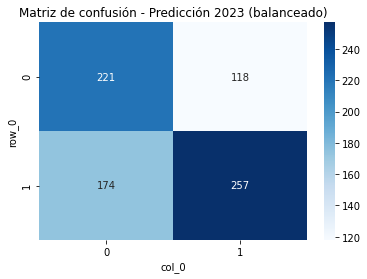

In [30]:

# ============================================================== 
# 12. Predicción y evaluación
# ============================================================== 
print("Realizando predicciones...")
probs = voting.predict_proba(X_test_scaled)[:, 1]

# Optimización del threshold usando F1 macro
best_thresh = 0.5
best_f1 = 0
for t in np.arange(0.3, 0.7, 0.01):
    p = (probs > t).astype(int)
    f1_local = f1_score(y_test, p, average='binary')
    f1_visitante = f1_score(1 - y_test, 1 - p, average='binary')
    f1_macro = (f1_local + f1_visitante) / 2
    if f1_macro > best_f1:
        best_f1 = f1_macro
        best_thresh = t

preds = (probs > best_thresh).astype(int)
acc = accuracy_score(y_test, preds)

print(f"Threshold óptimo: {best_thresh:.2f}")
print(f"Accuracy 2023 balanceado: {acc * 100:.2f}%")
print(classification_report(y_test, preds, target_names=['VISITANTE', 'LOCAL']))

# Matriz de confusión
sns.heatmap(pd.crosstab(y_test, preds), annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de confusión - Predicción 2023 (balanceado)")
plt.show()